### Import Packages

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### Load Data

In [2]:
# file_path = '/Users/baselhussein/Projects/impossible_goals/brick_wall/data/cluster_features_quit.csv'
# id_list = '/Users/baselhussein/Projects/impossible_goals/agg/data/ids_evaluation.csv'

In [3]:
# df_import = pd.read_csv(file_path)
# df_ids = pd.read_csv(id_list)

In [4]:
# df = pd.merge(df_import, df_ids)
df_win = pd.read_csv('/Users/baselhussein/Projects/impossible_goals/brick_wall/data/cluster_features.csv')
df_quit = pd.read_csv('/Users/baselhussein/Projects/impossible_goals/brick_wall/data/cluster_features_quit.csv')

In [5]:
df = pd.concat([df_win, df_quit], axis=0)

In [6]:
df.head()

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
0,2,2,2,18.233000,13.416,7,110,82.466,7.000000
1,6,2,0,4.408000,8.816,0,15,13.050,0.000000
2,12,7,11,12.821286,17.533,17,230,148.016,1.666667
3,13,6,3,18.163833,9.300,52,365,281.800,8.200000
4,22,2,0,7.533500,15.067,9,31,24.300,9.000000


In [7]:
df.describe()

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
count,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000
mean,146.762500,4.237500,7.193750,31.447683,14.728819,29.668750,165.531250,230.848919,6.668564
std,73.634956,1.642546,9.414626,32.707573,10.467504,36.353734,191.403848,268.103877,6.224069
min,2.000000,2.000000,0.000000,2.425000,0.383000,0.000000,8.000000,8.900000,0.000000
25%,82.500000,3.000000,1.000000,9.656950,7.804250,8.000000,34.750000,60.862000,2.729167
50%,158.500000,4.000000,3.000000,17.978500,12.608500,16.000000,108.500000,121.633500,5.000000
75%,210.250000,5.000000,9.000000,42.333425,18.379250,37.500000,216.250000,305.807750,8.500000
max,258.000000,9.000000,50.000000,185.694857,82.550000,178.000000,1030.000000,1915.750000,34.600000


### Preprocessing

#### Drop Outliers

In [8]:
def remove_outliers(df, threshold=3):
    """
    Remove outliers that are more than `threshold` standard deviations from the mean.
    """
    for column in df.columns:
        mean = df[column].mean()
        std = df[column].std()
        lower_bound, upper_bound = mean - threshold * std, mean + threshold * std
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

In [9]:
data = remove_outliers(df)

In [10]:
data.describe()

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
count,138.000000,138.000000,138.000000,138.000000,138.00000,138.000000,138.000000,138.000000,138.000000
mean,145.028986,4.000000,4.724638,22.800232,13.87350,18.876812,116.833333,155.709254,4.933782
std,74.279698,1.454919,5.039650,19.705744,8.57831,17.378757,112.395586,142.181798,3.545082
min,2.000000,2.000000,0.000000,2.425000,0.38300,0.000000,8.000000,8.900000,0.000000
25%,80.250000,3.000000,1.000000,8.258250,7.66625,7.000000,31.000000,51.392000,2.500000
50%,153.000000,4.000000,3.000000,15.701700,11.72450,13.500000,79.000000,99.175000,4.000000
75%,209.750000,5.000000,7.000000,33.247138,17.58325,26.500000,162.750000,237.592000,6.687500
max,257.000000,8.000000,23.000000,102.930000,39.35000,75.000000,524.000000,603.234000,16.750000


#### Explore Data Relationships

In [11]:
df_numeric = data.drop(columns=['ID'])

In [12]:
correlation_matrix = df_numeric.corr()
correlation_matrix

,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
unique_goals,1.000000,0.701826,0.404823,0.072842,0.658198,0.724542,0.698598,0.262986
total_returns,0.701826,1.000000,0.655168,0.041002,0.731347,0.718680,0.790451,0.469349
seconds_per_goal,0.404823,0.655168,1.000000,0.304720,0.609385,0.428778,0.866332,0.589014
seconds_to_first_goal_switch,0.072842,0.041002,0.304720,1.000000,0.083087,0.007896,0.233239,0.154442
impasses,0.658198,0.731347,0.609385,0.083087,1.000000,0.695139,0.763556,0.807629
input_count_exploring,0.724542,0.718680,0.428778,0.007896,0.695139,1.000000,0.746250,0.327951
time_in_level_seconds,0.698598,0.790451,0.866332,0.233239,0.763556,0.746250,1.000000,0.524065
avg_impasse_per_goal,0.262986,0.469349,0.589014,0.154442,0.807629,0.327951,0.524065,1.000000


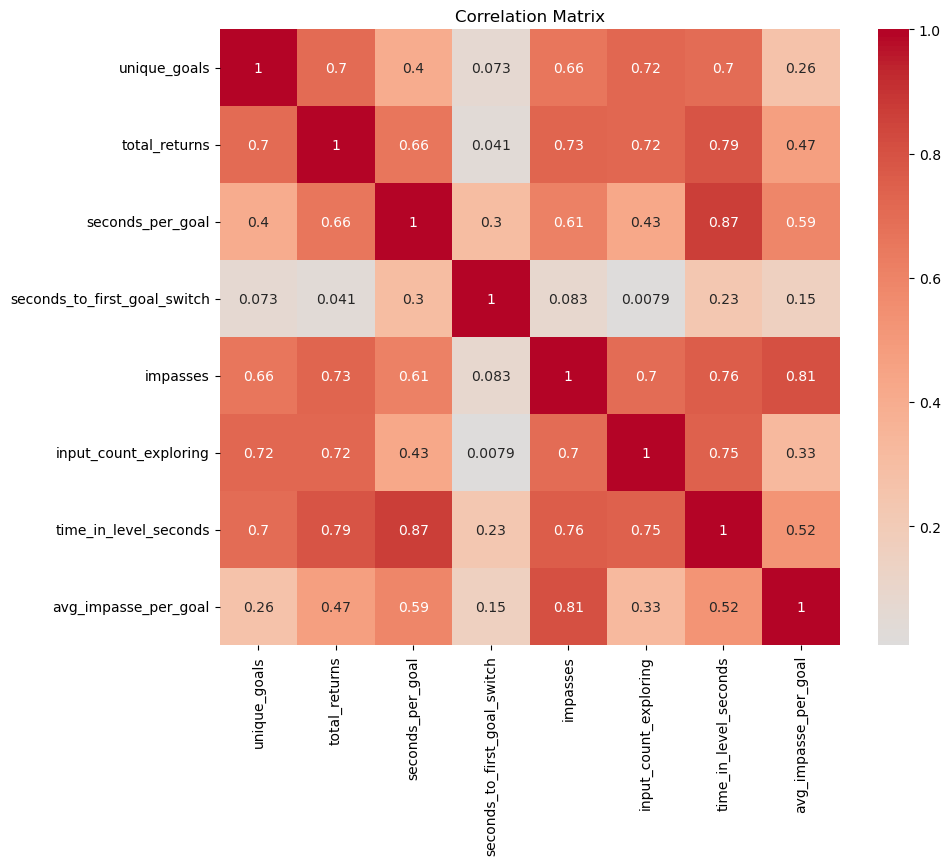

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

### Keep Relevant Features

In [14]:
data_numeric = df_numeric.drop(columns=['input_count_exploring', 'time_in_level_seconds', 
                                'seconds_per_goal', 'unique_goals', 'impasses', 'avg_impasse_per_goal',
                                'impasses'])
data_numeric

,total_returns,seconds_to_first_goal_switch
0,2,13.416
1,0,8.816
2,11,17.533
3,3,9.300
4,0,15.067
...,...,...
2,0,21.767
3,7,8.000
6,3,20.133
8,15,14.650


In [15]:
# data_numeric = remove_outliers(data_numeric)
# data_numeric

In [16]:
data_numeric.describe()

,total_returns,seconds_to_first_goal_switch
count,138.000000,138.00000
mean,4.724638,13.87350
std,5.039650,8.57831
min,0.000000,0.38300
25%,1.000000,7.66625
50%,3.000000,11.72450
75%,7.000000,17.58325
max,23.000000,39.35000


#### Normalize Data

In [17]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_numeric)

### Model

#### Hierarchical Clustering

In [18]:
linked = linkage(data_scaled, method='ward')

#### Visualize Dendrogram

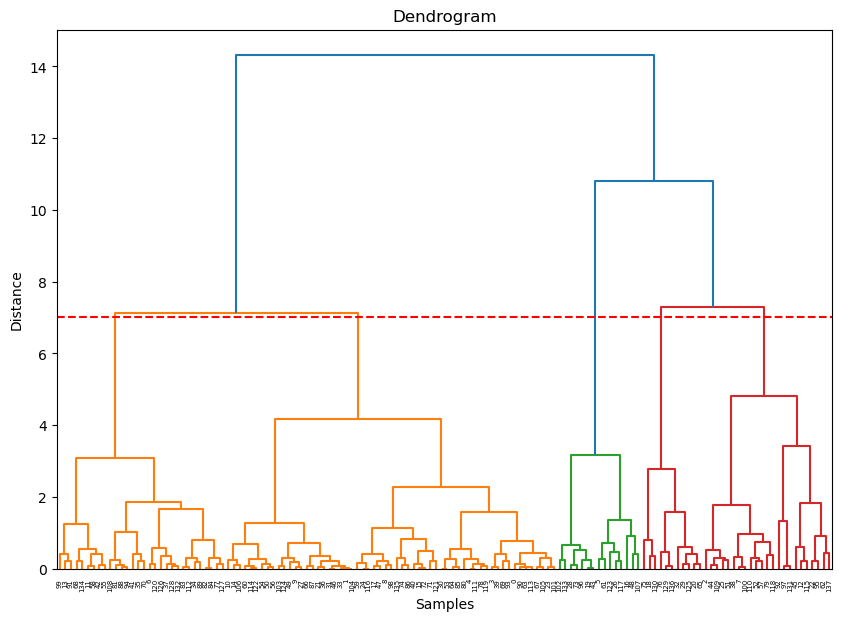

In [19]:
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', no_labels=False)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.axhline(y=7, color='r', linestyle='--')  # Check threshold
plt.show()

### Evaluate Threshold for Clusters 

In [20]:
# Function to calculate silhouette score for different thresholds
def evaluate_silhouette(linked, data_scaled, thresholds):
    best_threshold = None
    best_score = -1
    scores = []
    
    for threshold in thresholds:
        labels = fcluster(linked, threshold, criterion='distance')
        score = silhouette_score(data_scaled, labels)
        scores.append((threshold, score))
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
    
    return best_threshold, best_score, scores

# Define a range of thresholds to evaluate
thresholds = np.arange(1, 14, 0.5)

# Evaluate silhouette score for different thresholds
best_threshold, best_score, scores = evaluate_silhouette(linked, data_scaled, thresholds)

print(f"Best Threshold: {best_threshold}")
print(f"Best Silhouette Score: {best_score}")

# Display scores for each threshold
for threshold, score in scores:
    print(f"Threshold: {threshold}, Silhouette Score: {score}")

Best Threshold: 7.5
Best Silhouette Score: 0.4342149155402078
Threshold: 1.0, Silhouette Score: 0.4183694242172342
Threshold: 1.5, Silhouette Score: 0.3909112668455831
Threshold: 2.0, Silhouette Score: 0.3541147607929017
Threshold: 2.5, Silhouette Score: 0.36598004803835504
Threshold: 3.0, Silhouette Score: 0.3570456450237115
Threshold: 3.5, Silhouette Score: 0.35876838738850475
Threshold: 4.0, Silhouette Score: 0.35876838738850475
Threshold: 4.5, Silhouette Score: 0.40338201724757744
Threshold: 5.0, Silhouette Score: 0.3901454019898466
Threshold: 5.5, Silhouette Score: 0.3901454019898466
Threshold: 6.0, Silhouette Score: 0.3901454019898466
Threshold: 6.5, Silhouette Score: 0.3901454019898466
Threshold: 7.0, Silhouette Score: 0.3901454019898466
Threshold: 7.5, Silhouette Score: 0.4342149155402078
Threshold: 8.0, Silhouette Score: 0.4342149155402078
Threshold: 8.5, Silhouette Score: 0.4342149155402078
Threshold: 9.0, Silhouette Score: 0.4342149155402078
Threshold: 9.5, Silhouette Score:

### Label Data w/ Clusters @ Threshold

In [24]:
# Form flat clusters using the specified threshold
threshold = 7.5
clusters = fcluster(linked, t=threshold, criterion='distance')

# Add the cluster labels to the original dataset
data['cluster'] = clusters

# Display the first few rows of the updated dataset
data.head()

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal,cluster
0,2,2,2,18.233000,13.416,7,110,82.466,7.000000,1
1,6,2,0,4.408000,8.816,0,15,13.050,0.000000,1
2,12,7,11,12.821286,17.533,17,230,148.016,1.666667,3
3,13,6,3,18.163833,9.300,52,365,281.800,8.200000,1
4,22,2,0,7.533500,15.067,9,31,24.300,9.000000,1


### Clean Data

In [25]:
data_export = data.drop(columns=['input_count_exploring', 'time_in_level_seconds', 
                                'seconds_per_goal', 'unique_goals', 'impasses', 'avg_impasse_per_goal',
                                'impasses'])
data_export

,ID,total_returns,seconds_to_first_goal_switch,cluster
0,2,2,13.416,1
1,6,0,8.816,1
2,12,11,17.533,3
3,13,3,9.300,1
4,22,0,15.067,1
...,...,...,...,...
2,101,0,21.767,2
3,157,7,8.000,1
6,178,3,20.133,1
8,234,15,14.650,3


### Explore Clusters

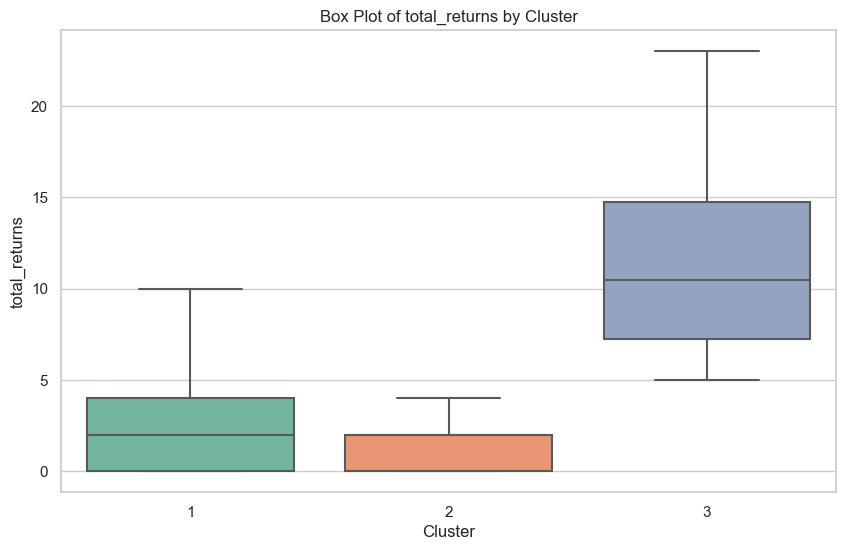

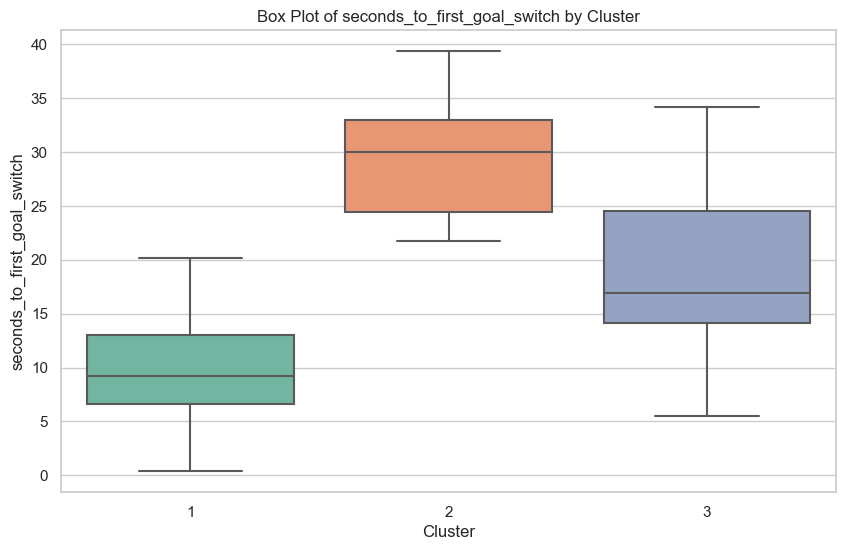

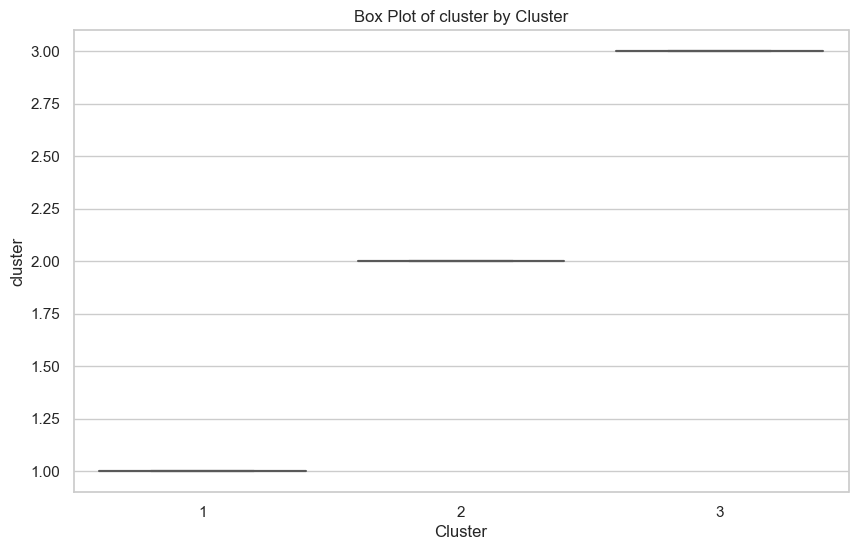

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# Function to create box plots for each numeric column grouped by 'Cluster'
def plot_boxplots(data_export, numeric_columns):
    for column in numeric_columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=data_export, x='cluster', y=column, palette='Set2')
        plt.title(f'Box Plot of {column} by Cluster')
        plt.xlabel('Cluster')
        plt.ylabel(column)
        plt.show()


# List of numeric columns
numeric_columns = data_export.columns[data_export.dtypes != 'object'].tolist()
numeric_columns.remove('ID')  # Exclude ID as it's not a relevant numeric column for analysis


# Plot box plots
plot_boxplots(data_export, numeric_columns)

In [102]:
# Define the mapping
cluster_mapping = {
    1: 'low-returns_fast-reframe',
    2: 'high-returns_fast-reframe',
    3: 'low-returns_slow-reframe'
    # Add more mappings as needed
}

# Add a new column based on the 'cluster' column
data_export['cluster-category-bw'] = data_export['cluster'].map(cluster_mapping)

In [103]:
# data_export['cluster-category'] = data_export['cluster-category'] + "_bw"

In [104]:
data_export

,ID,total_returns,seconds_to_first_goal_switch,cluster,cluster-category-bw
0,2,2,13.416,1,low-returns_fast-reframe
1,6,0,8.816,1,low-returns_fast-reframe
2,12,11,17.533,3,low-returns_slow-reframe
3,13,3,9.300,1,low-returns_fast-reframe
4,22,0,15.067,1,low-returns_fast-reframe
...,...,...,...,...,...
143,248,4,7.817,1,low-returns_fast-reframe
144,251,3,2.500,1,low-returns_fast-reframe
145,252,15,14.133,2,high-returns_fast-reframe
147,255,20,8.283,2,high-returns_fast-reframe


### Export Data

In [105]:
# data_export.to_csv('/Users/baselhussein/Projects/impossible_goals/agg/data/bw_clusters.csv', index=False)